In [4]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.nddata import NDData
from astropy.visualization import simple_norm
from photutils.detection import find_peaks
from photutils.psf import EPSFBuilder, extract_stars
from photutils.psf import IntegratedGaussianPRF
from photutils.aperture import CircularAperture
from astropy.table import Table
from astropy.modeling import models, fitting

/global/homes/c/chaseg/.conda/envs/gigalens/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


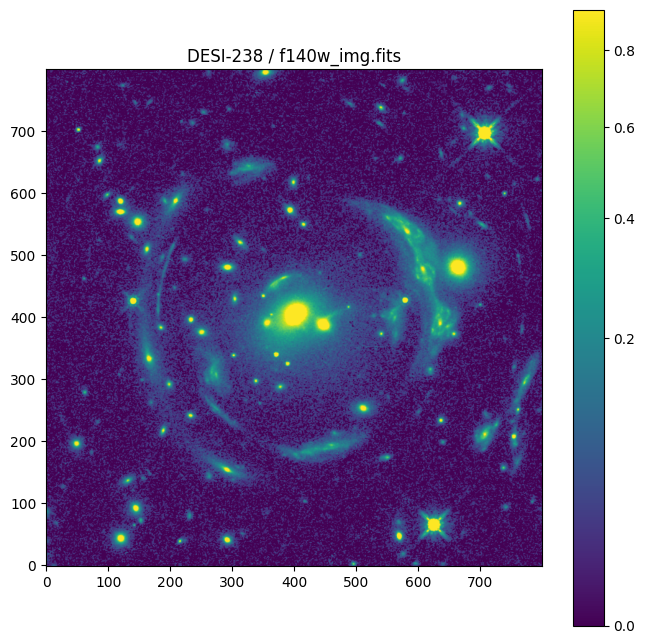

In [6]:
# visualize data
f = fits.open('f140w_img.fits')
imR = f[0].data
f.close()
imR[imR < 0] = 0
norm = simple_norm(imR, 'sqrt', percent=99.)
plt.figure(figsize=(8,8))
plt.imshow(imR, origin='lower', norm=norm, cmap='viridis')
plt.title('DESI-238 / f140w_img.fits')
plt.colorbar()
plt.show()

# PSF

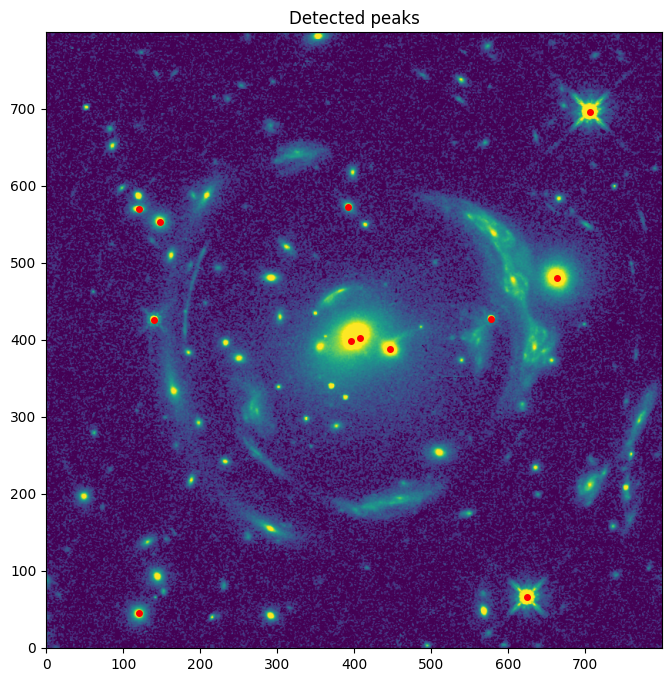

 x   y      peak_value    
--- --- ------------------
706 696 429.51495361328125
624  66      247.826171875
140 426   44.1776008605957
663 481 18.833351135253906
446 388 18.039031982421875
395 399  16.20414924621582
577 427  9.927879333496094
407 403  8.952563285827637
120 570  7.101536750793457
147 553  5.375171184539795
120  45  5.192417621612549
392 572  5.011420249938965


IndexError: index 2 is out of bounds for axis 0 with size 2

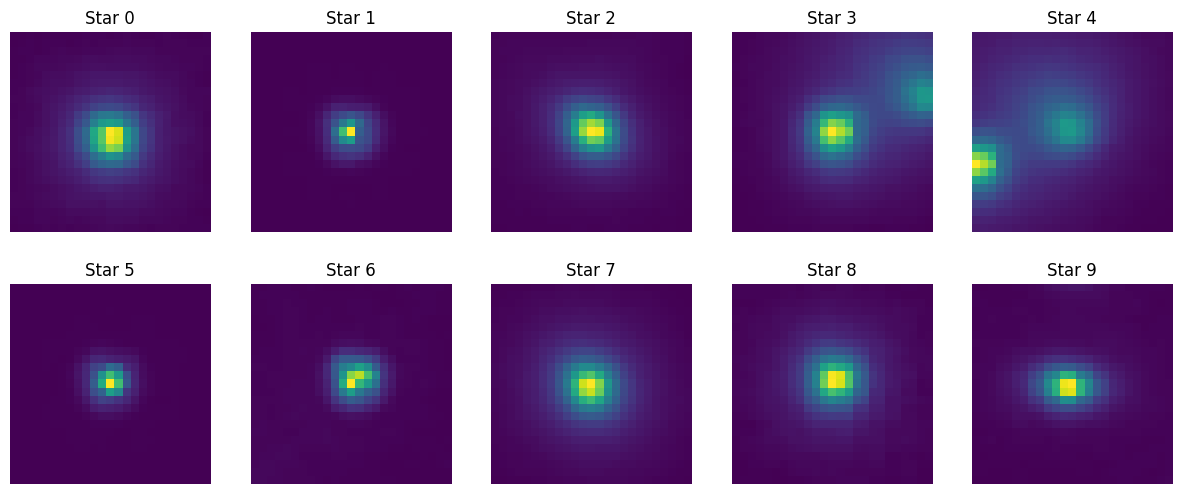

In [14]:
# find peaks in brightness
threshold = 5
peaks_tbl = find_peaks(imR, threshold=threshold)
# print(peaks_tbl)

# show detected stars
plt.figure(figsize=(8,8))
plt.imshow(imR, origin='lower', cmap='viridis', norm=norm)
plt.title('Detected peaks')
plt.plot(peaks_tbl['x_peak'], peaks_tbl['y_peak'], 'ro', markersize=4)
plt.show()

catalog = Table()
catalog['x'] = peaks_tbl['x_peak']
catalog['y'] = peaks_tbl['y_peak']
stars = extract_stars(NDData(imR), catalog, size=25)
catalog['peak_value'] = peaks_tbl['peak_value']
catalog.sort('peak_value', reverse=True)
print(catalog)

n_stars = len(stars)
n_cols = 5
n_rows = np.ceil(n_stars // n_cols)
fig, axes = plt.subplots(int(n_rows), int(n_cols), figsize=(n_cols*3, n_rows*3))
for i, star in enumerate(stars):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row, col]
    im = ax.imshow(star.data, origin='lower', cmap='viridis')
    ax.set_title(f'Star {i}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [15]:
# extract stars i want
stars_to_use = stars[:11]

EPSFBuilder (1 maxiters): 100%|██████████| 1/1 [00:00<00:00, 11.08it/s]


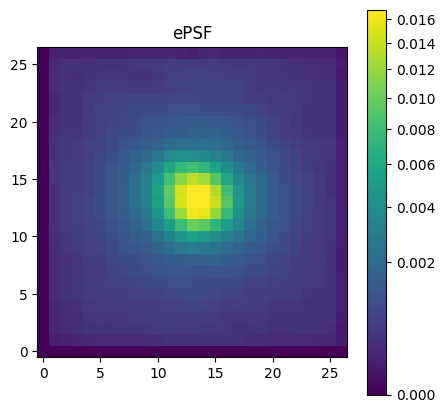

In [17]:
# build epsf
builder = EPSFBuilder(maxiters=1, oversampling=1)
epsf, fitted_stars = builder.build_epsf(stars_to_use)
psf_array = epsf.data.astype(np.float32)
np.save('psf.npy', psf_array)

# visualize epsf
plt.figure(figsize=(5,5))
plt.imshow(epsf.data, origin='lower', norm=simple_norm(epsf.data, 'sqrt', percent=99.), cmap='viridis')
plt.colorbar()
plt.title('ePSF')
plt.show()